In [1]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst
"""Spectrum 1D ON/OFF Analysis"""

'Spectrum 1D ON/OFF Analysis'

# Spectrum 1D ON/OFF Analysis with 1LHAASO Catalog


This notebook demonstrates how to:
1. Import necessary libraries and modules.
2. Load and select a source from the 1LHAASO catalog.
3. Configure an `AnalysisSpectrumConfig` object.
4. Perform spectrum analysis using `AnalysisSpectrum`.
5. Save and inspect the results, including flux points and fit results.

---


In [2]:
# Standard library imports
import astropy.units as u

# Third-party imports from gammapy
from gammapy.catalog import SourceCatalog1LHAASO
from gammapy.data import Observation
from gammapy.datasets import Datasets
from gammapy.utils.scripts import make_path
from gammapy.modeling.models import PowerLawSpectralModel, SkyModel, Models

# Third-party imports from regions
from regions import CircleSkyRegion

# feupy module imports
from feupy.utils.coordinates import convert_skycoord_to_dict
from feupy.analysis.config import CTAOAnalysisConfig
from feupy.analysis.core import CTAOAnalysis
from feupy.visualization.counts import show_hist_counts

from feupy.irf import (
CTAOVisibilityEstimator,
make_ctao_visibility_table,
)

### 1. Load and Select Source
In this section, we load the 1LHAASO catalog and select a specific source (1LHAASO J1219+2915) for analysis.

In [3]:
# Load the 1LHAASO catalog and select a source
catalog = SourceCatalog1LHAASO()

In [4]:
source = catalog["1LHAASO J2002+3244u"]

### Annual Visibility

In [5]:
year=2026

estimator = CTAOVisibilityEstimator(
    target=source.position,
    year=year,
    time_step_min=30,
)

df = make_ctao_visibility_table(estimator)

df

cta_south:  79%|███████████████████████▊      | 290/365 [00:13<00:03, 20.85it/s]


KeyboardInterrupt: 

### 2. Configure `CTAOAnalysis`
Here, we configure the `CTAOAnalysisConfig` object with observation, dataset, and analysis settings for the spectrum analysis.

In [6]:
config = CTAOAnalysisConfig()

position = source.position.icrs

config.observation.obs_cone = convert_skycoord_to_dict(position)
config.observation.position_angle = 0 * u.deg
config.observation.offset = 0.5 * u.deg
config.observation.livetime = 50 * u.h
config.observation.required_irfs = ["South", "AverageAz", "40deg", "50h"]

config.datasets.map_selection = ["edisp", "background", "exposure"]

config.datasets.safe_mask.methods = ["aeff-default"]
config.datasets.safe_mask.parameters = {"aeff_percent": 10}

config.datasets.containment_correction = False
config.datasets.use_region_center = True

config.datasets.on_region = convert_skycoord_to_dict(position)
config.datasets.on_region.radius = 0.2 * u.deg

config.datasets.stack = False

config.datasets.on_off.acceptance = 1
config.datasets.on_off.acceptance_off = 5

config.datasets.geom.axes.energy.min = 3 * u.GeV
config.datasets.geom.axes.energy.max = 100 * u.TeV
config.datasets.geom.axes.energy.nbins = 15

config.datasets.geom.axes.energy_true.min = .3 * u.GeV
config.datasets.geom.axes.energy_true.max = 300 * u.TeV
config.datasets.geom.axes.energy_true.nbins = 20

config.flux_points.energy.min = 3 * u.GeV
config.flux_points.energy.max = 100 * u.TeV
config.flux_points.energy.nbins = 15
config.flux_points.source = "source"

config.sensitivity.gamma_min = 3
config.sensitivity.n_sigma = 2
config.sensitivity.bkg_syst_fraction = 0.05

config.statistics.n_obs = 1

DATA_PATH = make_path("./data/")
DATA_PATH.mkdir(parents=True, exist_ok=True)

config.sensitivity.data_path = DATA_PATH

print(config)

CTAOAnalysisConfig

    general:
        log: {level: info, filename: null, filemode: null, format: null, datefmt: null}
        outdir: .
        n_jobs: 1
        datasets_file: null
        models_file: null
    observation:
        obs_cone: {frame: icrs, lon: 300.6399932258911 deg, lat: 32.73999395571273 deg,
            radius: null}
        livetime: 50.0 h
        offset: 0.5 deg
        position_angle: 0.0 deg
        required_irfs: [South, AverageAz, 40deg, 50h]
    datasets:
        type: 1d
        stack: false
        geom:
            wcs:
                skydir: {frame: null, lon: null, lat: null}
                binsize: 0.02 deg
                width: {width: 5.0 deg, height: 5.0 deg}
                binsize_irf: 0.2 deg
            selection: {offset_max: 2.5 deg}
            axes:
                energy: {min: 3.0 GeV, max: 100.0 TeV, nbins: 15}
                energy_true: {min: 0.3 GeV, max: 300.0 TeV, nbins: 20}
        map_selection: [edisp, background, exposure]

### 3. Running Spectrum Analysis
In this section, we create an instance of `CTAOAnalysis` and perform the spectrum analysis based on the configured settings. The process includes simulating observations, running fits, and extracting flux points.

In [7]:
# Create and run spectrum analysis
analysis = CTAOAnalysis(config)

# Simulate observation and spectrum
analysis.simulate_observation()

INFO:feupy.analysis.config:Setting logging config: {'level': 'INFO', 'filename': None, 'filemode': None, 'format': None, 'datefmt': None}
INFO:feupy.analysis.core:Observation 0 created


In [8]:
source.spectral_model("WCDA")

In [9]:
model_simu =  PowerLawSpectralModel(
    index=2.21,
    amplitude=3.4e-14 * u.Unit("cm-2 s-1 TeV-1"),
    reference=3* u.TeV,
)
model_source = SkyModel(spectral_model=model_simu, name="source")
analysis.get_spectrum_dataset(model_source)

INFO:feupy.analysis.core:
Corrected exposure (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         : 27729.67
  Total excess counts             : -27729.67

  Predicted counts                : 27729.67
  Predicted background counts     : 27729.67
  Predicted excess counts         : nan

  Exposure min                    : 4.09e-10 m2 s
  Exposure max                    : 4.00e+11 m2 s

  Number of total bins            : 15 
  Number of fit bins              : 15 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0



INFO:feupy.analysis.core:
Corrected background (containment: 0.68%):
SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 0 
  Total background counts         :

In [10]:
print(analysis.spectrum_dataset)

SpectrumDataset
---------------

  Name                            : 0 

  Total counts                    : 14358 
  Total background counts         : 12031.14
  Total excess counts             : 2326.86

  Predicted counts                : 14252.29
  Predicted background counts     : 12031.14
  Predicted excess counts         : 2221.16

  Exposure min                    : 4.09e-10 m2 s
  Exposure max                    : 4.00e+11 m2 s

  Number of total bins            : 15 
  Number of fit bins              : 11 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : -210955.37

  Number of models                : 1 
  Number of parameters            : 3
  Number of free parameters       : 2

  Component 0: SkyModel
  
    Name                      : source
    Datasets names            : None
    Spectral model type       : PowerLawSpectralModel
    Spatial  model type       : 
    Temporal model type       : 
    Parameters:
      index                      

In [11]:
analysis.get_datasets()

In [12]:
print(analysis.datasets)

Datasets
--------

Dataset 0: 

  Type       : SpectrumDatasetOnOff
  Name       : obs-0
  Instrument : CTA
  Models     : 




In [13]:
analysis.datasets.info_table()

name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str5,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
obs-0,14349,2329.999999999998,18.72319566701297,12019.000000000002,12407.333333333336,12407.333333333336,nan,4.0947089427510584e-10,400053877365.51337,180000.0,180000.0,0.07971666666666667,0.06677222222222223,0.012944444444444434,15,11,wstat,1919.6660522642967,60095,11.0,54.999999999999986,0.20000000000000004


In [14]:
analysis.set_models(Models(model_source))

INFO:feupy.analysis.core:Reading model.
INFO:feupy.analysis.core:Models

Component 0: SkyModel

  Name                      : source
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type       : 
  Temporal model type       : 
  Parameters:
    index                         :      2.210   +/-    0.00             
    amplitude                     :   3.40e-14   +/- 0.0e+00 1 / (TeV s cm2)
    reference             (frozen):      3.000       TeV         




In [15]:
print(analysis.datasets)

Datasets
--------

Dataset 0: 

  Type       : SpectrumDatasetOnOff
  Name       : obs-0
  Instrument : CTA
  Models     : ['source']




In [16]:
analysis.get_file_name()

'sens_CTAO-South_40deg_50h_livetime50.0h'

In [17]:
analysis.run_fit()

In [18]:
analysis.fit_result.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,2.1986e+00,,2.548e-02,nan,nan,False,,
,amplitude,3.5697e-14,TeV-1 s-1 cm-2,1.437e-15,nan,nan,False,,
,reference,3.0000e+00,TeV,0.000e+00,nan,nan,True,,


In [19]:
analysis.get_flux_points()

In [20]:
analysis.flux_points

In [21]:
# Run the sensitivity analysis
analysis.compute_sensitivity()

# Write the sensitivity table to a file (CSV in this case)
analysis.write_table_sensitivity()

# Read the sensitivity table back if needed
sensitivity_table = analysis.read_table_sensitivity()

# Print the sensitivity table summary
print("\nSensitivity Table:")
print(sensitivity_table)

/home/phoenix/miniconda3/envs/feupy/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
INFO:gammapy.estimators.points.core:Inferred format: gadf-sed
INFO:feupy.analysis.core:Table (sens_CTAO-South_40deg_50h_livetime50.0h.fits) stored to data.



Sensitivity Table:
      e_ref              e_min        ...     background      criterion  
       GeV                GeV         ...                                
------------------ ------------------ ... ------------------ ------------
 4.245060455378107 3.0000000000000004 ...                0.0        gamma
 8.499808265979931 6.0068460899383265 ...                0.0        gamma
 17.01901334924234 12.027399982735789 ...                0.0        gamma
 34.07686459716817 24.082246852806918 ...                0.0        gamma
 68.23149362095243  48.21945011490426 ... 2613.6000000000004          bkg
 136.6186935558901  96.54893846056295 ...             7775.0          bkg
 273.5491550662272 193.31820449317635 ...             1345.4 significance
  547.722557505166 387.07756692457804 ...              222.4 significance
1096.6950343069764  775.0384564612474 ... 61.400000000000006 significance
2195.8927595605446 1551.8455739153599 ... 12.600000000000001 significance
 4396.796612230041

In [22]:
table_sens = analysis.table_sens

<Axes: xlabel='Energy [$\\mathrm{GeV}$]', ylabel='Flux Sensitivity [$\\mathrm{erg\\,s^{-1}\\,cm^{-2}}$]'>

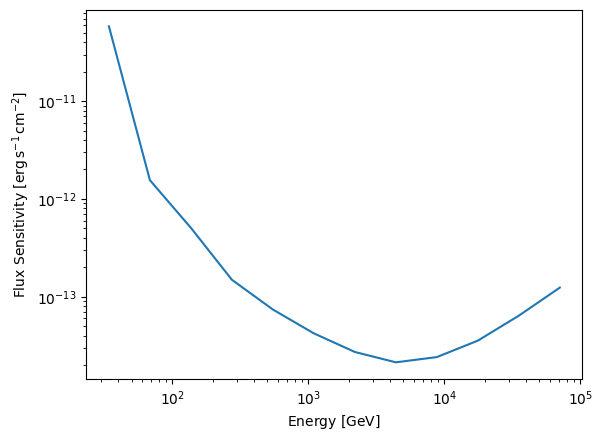

In [23]:
from feupy.visualization.sensitivity import plot_sensitivity_from_table

plot_sensitivity_from_table(table_sens)

In [24]:
table = analysis.table_sens
print(table[['e_ref', 'background', 'excess']])

 e_ref  background  excess
  GeV                     
------- ---------- -------
4.24506          0       3
8.49981          0       3
 17.019          0       3
34.0769          0       3
68.2315     2613.6  130.68
136.619       7775  388.75
273.549     1345.4 81.2931
547.723      222.4  33.603
 1096.7       61.4 18.0949
2195.89       12.6  8.6993
 4396.8        2.6 4.44896
8803.63        0.4       3
17627.3        0.4       3
35294.9          0       3
70670.4          0       3


In [25]:
table = analysis.datasets.info_table()
table

name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str5,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
obs-0,14349,2329.999999999998,18.72319566701297,12019.000000000002,14306.708085660075,12027.458507511563,2279.2495781485113,4.0947089427510584e-10,400053877365.51337,180000.0,180000.0,0.07971666666666667,0.06677222222222223,0.012944444444444434,15,11,wstat,9.838141916385538,60095,11.0,54.999999999999986,0.20000000000000004


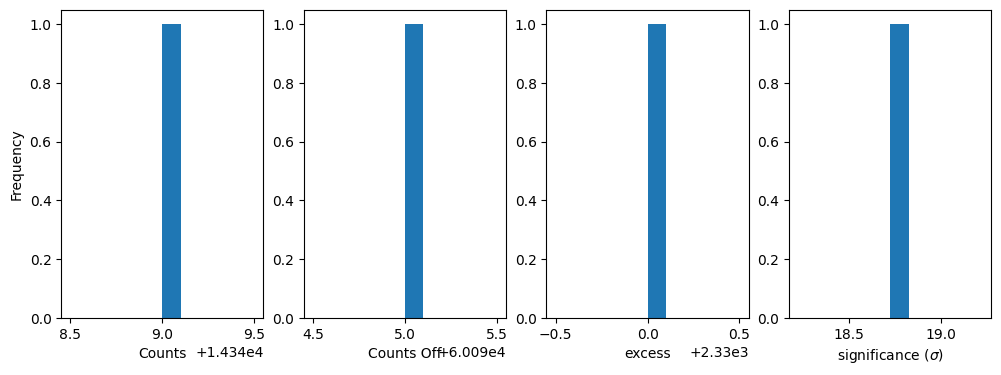

In [26]:
show_hist_counts(table)

In [27]:
analysis.flux_points.data.to_table()

INFO:gammapy.estimators.points.core:Inferred format: gadf-sed


e_ref,e_min,e_max,ref_dnde,ref_flux,ref_eflux,norm,norm_err,ts,sqrt_ts,npred,npred_excess,stat,stat_null,counts,success
GeV,GeV,GeV,1 / (TeV s cm2),1 / (s cm2),erg / (s cm2),,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[1],float32[1],float64,float64,float64[1],bool
4.245060455378107,3.0000000000000004,6.0068460899383265,6.562323012313013e-08,1.99040472670874e-10,1.316495036269108e-12,nan,nan,nan,nan,nan,0.0,0.0,0.0,0.0,False
8.499808265979931,6.0068460899383265,12.027399982735789,1.4259842926543018e-08,8.660117454474337e-11,1.1469034616862514e-12,nan,nan,nan,nan,nan,0.0,0.0,0.0,0.0,False
17.01901334924234,12.027399982735789,24.082246852806918,3.0986454020648207e-09,3.767959014511806e-11,9.991587618557671e-13,nan,nan,nan,nan,nan,0.0,0.0,0.0,0.0,False
34.07686459716817,24.082246852806918,48.21945011490426,6.733316332584007e-10,1.6394136926752063e-11,8.70446611021087e-13,nan,nan,nan,nan,nan,0.0,0.0,0.0,0.0,False
68.23149362095243,48.21945011490426,96.54893846056295,1.4631409197203178e-10,7.132979009006505e-12,7.583152263318378e-13,1.3973313721836447,0.6193869062688794,5.228163614607183,2.2865177923224613,2689.7170556459255,127.663155,3.543362254276872e-05,5.228199048229726,2690.0,True
136.6186935558901,96.54893846056295,193.31820449317635,3.1793862715171977e-11,3.1035113205564455e-12,6.606286648783063e-13,1.0092134473605665,0.13519256994901666,58.07772470661439,7.620874274426418,8545.996809335797,750.59625,1.3969838619232178e-09,58.077724708011374,8546.0,True
273.5491550662272,193.31820449317635,387.07756692457804,6.908765196345056e-12,1.3503169579863271e-12,5.755261370261758e-13,1.029327607369296,0.10031959301036611,120.09438595901884,10.958758413206253,1830.9366449799493,470.52722,2.5180052034556866e-06,120.09438847702404,1831.0,True
547.722557505166,387.07756692457804,775.0384564612474,1.5012657306169894e-12,5.875138508270468e-13,5.013865610286349e-13,1.0019617936678873,0.0738799556006979,271.8414431723322,16.487614841823913,555.9994561946949,332.3994,5.748006515204906e-10,271.841443172907,556.0,True


### 4. Inspect Results
Here, we review the results of the spectrum analysis, including the fit parameters and computed flux points.

In [28]:
# Display the fit parameters
print("Fit Parameters:")
print(analysis.fit_result)

# Display the flux points
print("Flux Points:")
print(analysis.flux_points)

Fit Parameters:
OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 39
	total stat : 9.84

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.

Flux Points:
FluxPointsDataset
-----------------

  Name                            : CvGlQoLj 

  Number of total flux points     : 15 
  Number of fit bins              : 11 

  Fit statistic type              : chi2
  Fit statistic value (-2 log(L)) : 10.81

  Number of models                : 1 
  Number of parameters            : 3
  Number of free parameters       : 2

  Component 0: SkyModel
  
    Name                      : source
    Datasets names            : None
    Spectral model type       : PowerLawSpectralModel
    Spatial  model type       : 
    Temporal model type       : 
    Parameters:
      index                         :      2.199   +/-    0.03             
 

(<Axes: xlabel='Energy [$\\mathrm{GeV}$]', ylabel='e2dnde [$\\mathrm{erg\\,s^{-1}\\,cm^{-2}}$]'>,
 <Axes: xlabel='Energy [$\\mathrm{GeV}$]', ylabel='Residuals\n (data - model) / model'>)

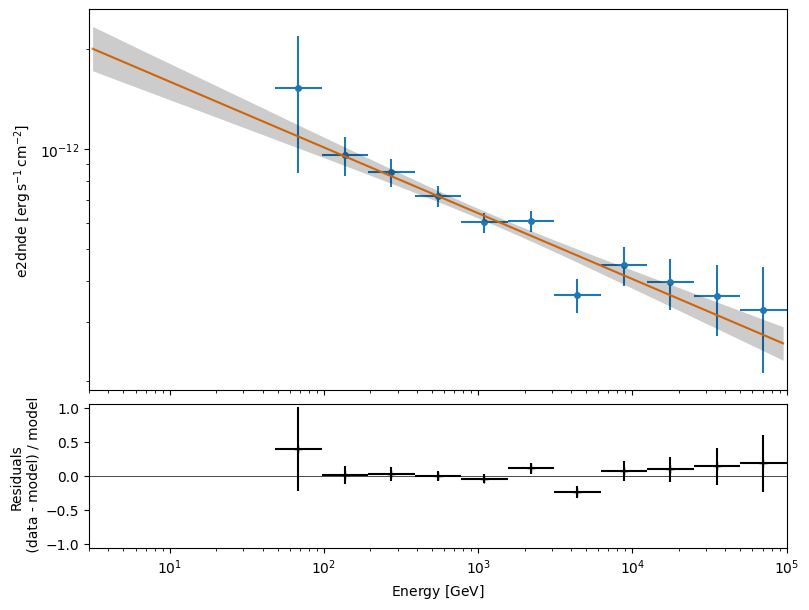

In [29]:
analysis.flux_points.plot_fit()

In [ ]:
from astropy.table import  Table

In [ ]:
table = Table.read("sens_CTAO-South_60deg_50h_livetime50.0h.fits")

In [ ]:
model = analysis.fit_result.models[0]

In [ ]:
from feupy.visualization.sensitivity import plot_irfs

In [ ]:
model

In [ ]:
plot_irfs([table_sens])

In [ ]:
ax = plot_irfs([table_sens], model, energy_bounds=[30 * u.GeV, (100 * u.TeV).to('GeV')])
fig = ax.get_figure()
fig.savefig("sens_CTAO.png", dpi=300, bbox_inches="tight")

## 5. Summary

In this notebook, we:

1. Selected a source from the 3HWC catalog.
2. Configured and ran a 1D ON/OFF spectrum analysis using `AnalysisSpectrum`.
3. Printed and saved the fit results and flux points for further analysis.

This modular design
